In [1]:
import argparse
import copy
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.functional import softmax
from torch.utils.data import DataLoader, Dataset, TensorDataset, Subset
from torchvision import datasets, transforms

from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler

import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Libs

## Utils

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


###################
# MODEL PERFORMANCES
###################

def stable_softmax(logits):
    # Numerically stable softmax
    predictions = torch.exp(logits - torch.max(logits, dim=-1, keepdims=True).values)
    predictions = predictions / torch.sum(predictions, dim=-1, keepdims=True)
    return predictions

def predict_labels(model, dl, device="cpu"):
    model.eval()
    y_pred, y_true = [], []

    with torch.no_grad():
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits = model(imgs)
            predictions = logits.argmax(dim=1)

            y_pred.append(predictions.cpu())
            y_true.append(lbls.cpu())
    
    return torch.cat(y_true), torch.cat(y_pred)

def predict_proba(model, dl, device="cpu", use_stable_softmax=False, return_labels = False):
    model.eval()
    probs, labels = [], []

    with torch.no_grad():
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits = model(imgs)
            if use_stable_softmax:
                p = stable_softmax(logits)
                probs.extend(p)
            else:
                probs.extend(F.softmax(logits, dim=1))

            if return_labels:
                labels.extend(lbls)
    
    if return_labels:
        return torch.stack(probs), torch.stack(labels)
    else:
        return torch.stack(probs)

def compute_logits(model, dl, device="cpu", return_labels = False):
    model.eval()
    logits, labels = [], []

    with torch.no_grad():
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits.extend(model(imgs))
            if return_labels:
                labels.extend(lbls)
    
    if return_labels:
        return torch.stack(logits), torch.stack(labels)
    else:
        return torch.stack(logits)

def predict_phi_scores(model, ds, device="cpu", return_labels=False):
    probs, labels = predict_proba(model, ds, device=device, use_stable_softmax=True, return_labels=True)
    probs, labels = probs.cpu().numpy(), labels.cpu().numpy()
    
    # Compute probability of the true class and the probability of all other classes
    # np.arange(predictions.shape[0]) is needed to correctly indexing of numpy array
    p_true = probs[np.arange(probs.shape[0]), labels]
    probs[np.arange(probs.shape[0]), labels] = 0
    p_wrong = np.sum(probs, axis=-1)

    # Compute phi
    eps = 1e-45
    phis = np.log(p_true + eps) - np.log(p_wrong + eps)
    
    if return_labels:
        return phis, labels
    else:
        return phis

def predict_losses(model, ds, device="cpu", return_labels=False):
    logits, labels = compute_logits(model, ds, device=device, return_labels=True)  
    losses = F.cross_entropy(logits, labels, reduction="none")

    losses, labels = losses.cpu().numpy(), labels.cpu().numpy()

    if return_labels:
        return losses, labels
    else:
        return losses

def get_labels(dl):
    labels = []
    for _, lbls in dl:
        labels.extend(lbls)
    
    return torch.tensor(labels)

def compute_accuracy(model, dl, device="cpu"):
    y_true, y_pred = predict_labels(model, dl, device=device)
    return accuracy_score(y_true=y_true, y_pred=y_pred)

def compute_error_rate(model, dl, device="cpu"):
    return 1 - compute_accuracy(model, dl, device=device)



###################
# SAVE AND LOAD UTILS
###################

def save_model(model, name, verbose=True, device="cpu"):
    if device=="cuda":
        torch.save(model.state_dict(), f"{name}.pth")
        if verbose:
            print(f"Model params saved in '{name}.pth'")
    
    model = model.to("cpu")
    torch.save(model.state_dict(), f"{name}_cpu.pth")
    if verbose:
        print(f"Model params saved in '{name}_cpu.pth'")
    
    model.to(device)

def load_model(model, name, verbose=True, device="cpu"):
    if device=="cpu":
        path = f"{name}_cpu.pth"
    else:
        path = f"{name}.pth"
    model.load_state_dict(torch.load(path))
    if verbose:
        print(f"Model loaded from '{path}'")

def save_array(arr, name, verbose=True):
    np.save(f"{name}.npy", arr)
    if verbose:
        print(f"Array saved in '{name}.npy'")

def load_array(name, verbose=True):
    arr = np.load(f"{name}.npy")
    if verbose:
        print(f"Array loaded from '{name}.npy'")
    return arr



###################
# PLOT UTILS
###################

def roc_chart(true_memberships, scores, axis: plt.Axes, color="darkorange", title="", log_scale=False):

    fpr, tpr, roc = roc_curve(true_memberships, scores)

    axis.plot(fpr, tpr, color=color, lw=1, label='ROC curve (area = %0.2f)' % auc(fpr, tpr))
    axis.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    if log_scale:
        axis.set_xlim([1e-5, 1.0])
        axis.set_ylim([1e-5, 1.0])
        axis.set_xscale("log")
        axis.set_yscale("log")
    else:
        axis.set_xlim([0, 1.0])
        axis.set_ylim([0, 1.0])
    axis.set_xlabel('False Positive Rate')
    axis.set_ylabel('True Positive Rate')
    if title!= "":
        axis.set_title(title)
    else:
        axis.set_title('ROC')
    axis.legend(loc="lower right")



###################
# MODEL ACTIVATION UTILS
###################

def get_activation(name, dict):
    def hook(model, input, output):
        dict[name] = output.detach()
    return hook

def get_activations(model, img):
    handles = []
    activations = {}

    for name, layer in model.named_modules():
        if name != "":
            handles.append(layer.register_forward_hook(get_activation(name, activations)))
    
    model(img)

    for handle in handles:
        handle.remove() 

    return activations



## FedAvg

In [3]:
import copy
from torch.utils.data import ConcatDataset, DataLoader
from typing import Any

###################
# CLASSES
###################

class Client:
    def __init__(self, id, ds, model, dl = None, data_idxs = None):
        self.id = id
        self.ds = ds
        self.dl = dl
        self.data_idxs = data_idxs
        self.model = model

class RoundLog:
    def __init__(self, round_, global_model, client_updates: dict[int, Any]):
        self.round = round_
        self.global_model = global_model
        self.client_updates = client_updates
    
    def get_partecipating_client_ids(self):
        return self.client_updates.keys()


###################
# FEDAVG
###################

def fedavg_from_state_dict(global_model, client_dicts, client_weights):
    global_model = copy.deepcopy(global_model)

    avg = {}
    total_weights = sum(client_weights)
    for key in client_dicts[0].keys():
        avg[key] = sum([client_weights[i]*cd[key] for i, cd in enumerate(client_dicts)]) / total_weights

    global_model.load_state_dict(avg)
    return global_model

def fedavg_with_weights(clients, client_weights):
    client_dicts = [c.model.state_dict() for c in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def fedavg_from_models(client_models, client_weights):
    client_dicts = [model.state_dict() for model in client_models]
    return fedavg_from_state_dict(client_models[0], client_dicts, client_weights)

def fedavg_data_based_weights(clients):
    client_dicts = [c.model.state_dict() for c in clients]
    client_weights = [len(c.ds) for c in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def fedavg(clients):
    client_dicts = [c.model.state_dict() for c in clients]
    client_weights = [1 for _ in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def train_client(train_fn, global_model, client, epochs, device="cpu", inplace=False):
    client_model = copy.deepcopy(global_model)

    train_fn(client_model, client.dl, epochs, device=device)

    if inplace:
        client.model = client_model

    return client_model

def train_fedavg(init_global_model, clients, rounds, epochs, train_fn, device="cpu", return_log=False, verbose=False, eval_dl = None):

    global_model = init_global_model
    if verbose:
        train_ds = ConcatDataset([c.ds for c in clients])
        train_dl = DataLoader(train_ds, batch_size=256)

    if return_log:
        logs = []
        global_model = global_model.cpu()
        logs.append(RoundLog(0, copy.deepcopy(global_model), {}))
        global_model = global_model.to(device)
    
    for r in range(1, rounds+1):
        client_updates = {}
        for client in clients:
            client_model = train_client(train_fn, global_model, client, epochs, device=device, inplace=False)
            if return_log:
                client_model = client_model.cpu()
                client_updates[client.id] = copy.deepcopy(client_model)
                client_model = client_model.to(device)
            client.model = client_model

        global_model = fedavg(clients)
        if return_log:
            global_model = global_model.cpu()
            logs.append(RoundLog(1, copy.deepcopy(global_model), client_updates))
            global_model = global_model.to(device)

        if verbose:
            #global_model = global_model.to(device)
            train_acc = compute_accuracy(global_model, train_dl, device=device)

            eval_acc = -1
            if eval_dl != None:
                eval_acc = compute_accuracy(global_model, eval_dl, device=device)
            
            print(f"Ended training for round {r}/{rounds}, train acc = {train_acc:.4f}, eval acc = {eval_acc:.4f}")

    if return_log:
        return global_model, logs
    else:
        return global_model


def fed_retrain(init_global_model, clients, client_ids_to_unlearn, rounds, epochs, train_fn, device="cpu", return_log=False, verbose=False, eval_dl = None):
    remaining_clients = [c for c in clients if c.id not in client_ids_to_unlearn]
    return train_fedavg(init_global_model, remaining_clients, rounds, epochs, train_fn, device=device, return_log=return_log, verbose=verbose, eval_dl = eval_dl)
###################


## Gradient Inversion for Data Reconstruction

In [4]:
def compute_tv_loss(x):
    diff_i = (x[:, :, 1:, :] - x[:, :, :-1, :]).abs().sum()
    diff_j = (x[:, :, :, 1:] - x[:, :, :, :-1]).abs().sum()
    return diff_i + diff_j

def data_reconstruction(target_model, target_grads, target_lbls, imgs, lr, max_iters, lambda_l2, lambda_tv, print_step=1000, loss_type="euclidean"):
    imgs.requires_grad_(True)
    target_model.eval()
    
    optimizer = torch.optim.Adam([imgs], lr=lr)
    criterion = nn.CrossEntropyLoss()

    for i in range(max_iters):
        optimizer.zero_grad()
        target_model.zero_grad()

        loss = criterion(target_model(imgs), target_lbls)

        grads = torch.autograd.grad(
            loss, target_model.parameters(),
            create_graph=True,
            retain_graph=True
        )

        grad_loss = 0.0
        if loss_type=="euclidean":
            for g, gt in zip(grads, target_grads):
                grad_loss += torch.norm(g - gt) ** 2
        elif loss_type=="cosine": 
            for g, gt in zip(grads, target_grads):
                grad_loss += nn.CosineSimilarity(dim=0)(g.view(-1), gt.view(-1))
        else:
            raise NotImplementedError()

        l2_loss = lambda_l2 * (imgs ** 2).sum()

        tv_loss = lambda_tv * compute_tv_loss(imgs)

        total_loss = grad_loss + l2_loss + tv_loss

        total_loss.backward()
        optimizer.step()

        if (i+1)%print_step==0:
            print(f"Ended epoch {i+1}/{max_iters}")
    
    return imgs.detach().cpu().numpy()


def data_reconstruction_test(target_model, target_imgs, target_lbls, imgs, lr, max_iters, lambda_l2, lambda_tv, print_step=1000, device="cpu", loss_type="euclidean", custom_labels = None):
    if custom_labels==None:
        custom_labels = target_lbls
    
    target_model.zero_grad()
    target_imgs, target_lbls, imgs, custom_labels = target_imgs.to(device), target_lbls.to(device), imgs.to(device), custom_labels.to(device)

    loss = nn.CrossEntropyLoss()(target_model(target_imgs), target_lbls)

    target_grads = torch.autograd.grad(loss, target_model.parameters(), create_graph=False, retain_graph=False)
    target_grads = [g.detach() for g in target_grads]

    return data_reconstruction(target_model, target_grads, custom_labels, imgs, lr, max_iters, lambda_l2, lambda_tv, print_step, loss_type=loss_type)



## Train Functions

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


def create_model(classes, device="cpu"):

    #########################
    # CustomCNN
    
    # model = CustomCNN()
    # model = model.to(device)
    
    #########################

    #########################
    # MOBILENETv2
    
    # model = torchvision.models.mobilenet_v2(weights=None)
    # model.features[0][0] = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
    # #model.features[0][0].stride = (1, 1)   # remove initial downsampling
    # model.classifier[1] = nn.Linear(model.last_channel, classes)
    # model = model.to(device)
    
    #########################

    #########################
    # RESNET18

    model = torchvision.models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, classes)
    model = model.to(device)

    #########################

    return model

In [6]:
def train_model(model, dl, lr, momentum, epochs, device="cpu", inplace=False):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    criterion = nn.CrossEntropyLoss()
    
    model.to(device)
    model.train()
    
    for e in range(epochs):
        for data, target in dl:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            pred = model(data)
            
            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()

    return model

In [7]:
LR = 0.001
MOMENTUM = 0.9
BATCH_SIZE = 128

def train(model, ds_train, ds_test, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

    train_dl = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
    test_dl = DataLoader(ds_test, batch_size=256)
    # Train
    for epoch in range(epochs):
        model.train()
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

        train_acc = compute_accuracy(model, train_dl, device=device)
        test_acc = compute_accuracy(model, test_dl, device=device)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f} - train acc: {train_acc:.4f} - test acc: {test_acc:.4f}")

# DS Load

In [8]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

IN_CH = 3
IN_W, IN_H = 32, 32
CLASSES = 10

NORMALIZATION_MEANS, NORMALIZATION_STDS = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)

# Load DS
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(NORMALIZATION_MEANS, NORMALIZATION_STDS)])
ds_train = CIFAR10(root="./data", train=True, download=True, transform=transform)
ds_test = CIFAR10(root="./data", train=False, download=True, transform=transform)

def show_img(img, axis):
    img = torch.tensor(img)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    img = img * std + mean
    axis.imshow(img.permute(1, 2, 0))


# Data Reconstruction from Local Gradients

## Single image reconstruction

/tmp/ipykernel_141/1140610116.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)


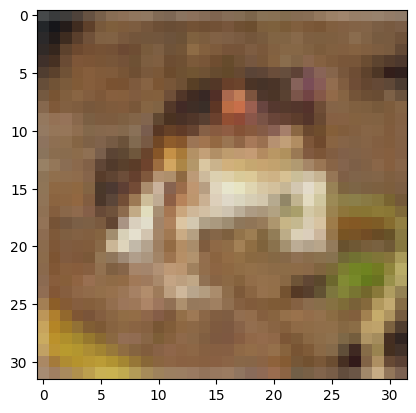

In [9]:
sample_batch_size = 1
sample_dl = DataLoader(ds_train, batch_size=sample_batch_size, shuffle=False)
target_imgs, target_lbls = next(iter(sample_dl))

_, axis = plt.subplots()
show_img(target_imgs[0], axis)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21925926..1.2136986].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4724974..1.3280475].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5845997..1.524036].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8190486..1.5055364].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.89011675..1.6259404].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9972477..1.690423].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.066682

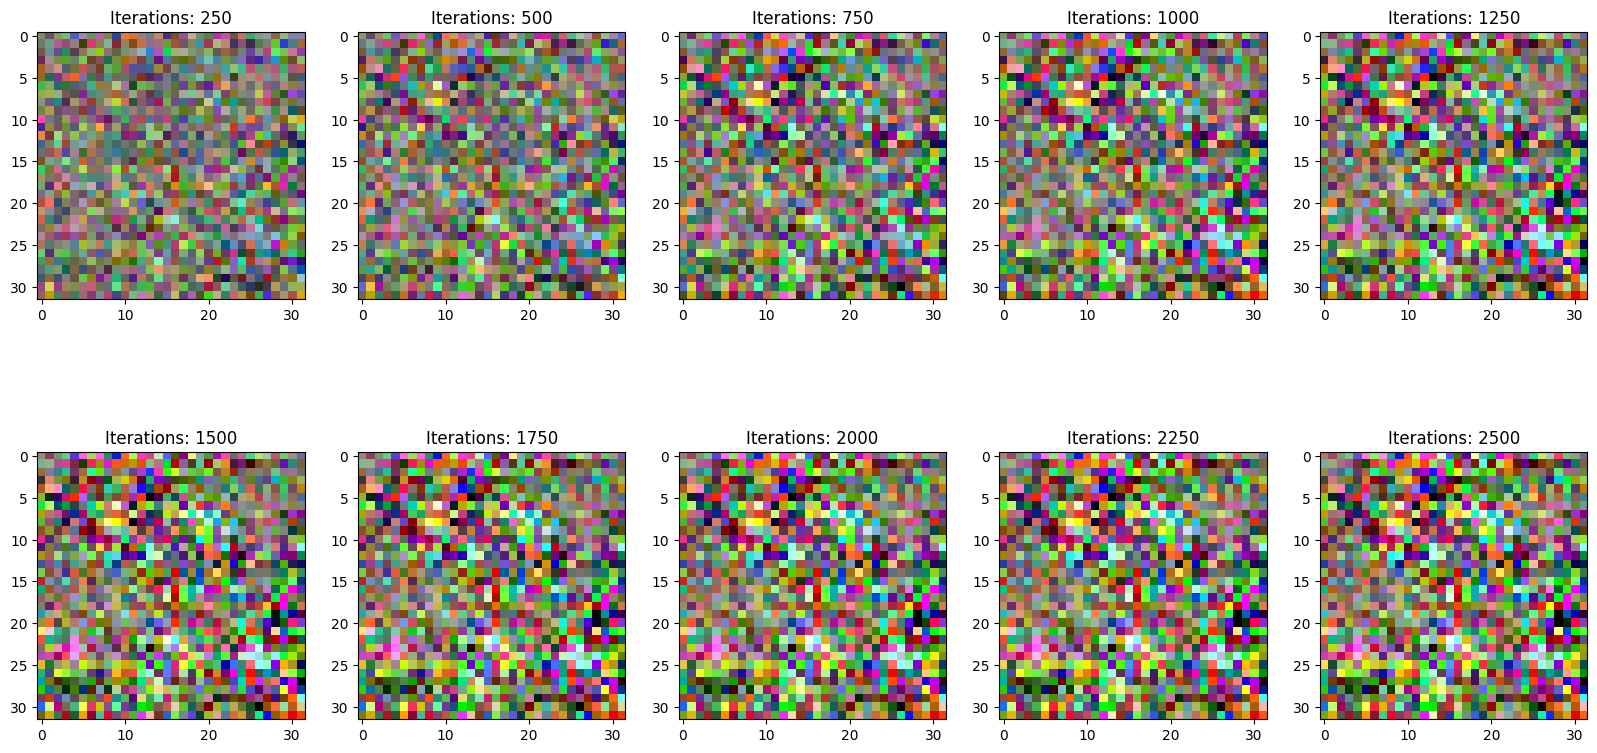

In [ ]:
# Training setup
target_model = create_model(CLASSES, device)
target_model.eval()

MAX_ITERS = 250
LAMBDA_L2 = 1e-6
LAMBDA_TV = 1e-6
ATT_LR = 0.01

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

target_imgs, target_lbls = target_imgs.to(device), target_lbls.to(device)

init_imgs = torch.randn(sample_batch_size, 3, 32, 32)
imgs = copy.deepcopy(init_imgs).to(device)
for i in range(10):
    imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, 
                                    device=device, loss_type="euclidean")
    axes[i].set_title(f"Iterations: {(i+1)*MAX_ITERS}")
    show_img(imgs[0], axes[i])
    imgs = torch.tensor(imgs)


## Batch Data Reconstruction

/tmp/ipykernel_141/1140610116.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)


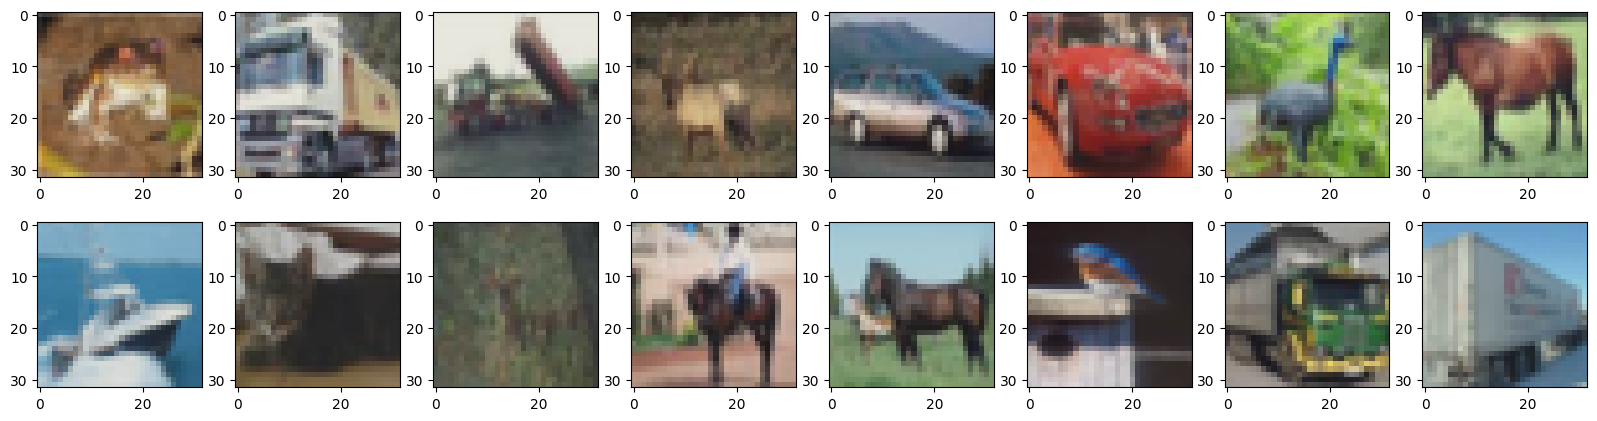

In [ ]:
sample_batch_size = 16
sample_dl = DataLoader(ds_train, batch_size=sample_batch_size, shuffle=False)
target_imgs, target_lbls = next(iter(sample_dl))

_, axes = plt.subplots(2, 8, figsize=(20, 5))
axes = axes.flatten()
for i in range(sample_batch_size):
    show_img(target_imgs[i], axes[i])

In [44]:
def compute_tv_loss(x):
    diff_i = (x[:, :, 1:, :] - x[:, :, :-1, :]).abs().sum()
    diff_j = (x[:, :, :, 1:] - x[:, :, :, :-1]).abs().sum()
    return diff_i + diff_j

def data_reconstruction(target_model, target_grads, target_lbls, imgs, lr, max_iters, lambda_l2, lambda_tv, print_step=1000, loss_type="euclidean", use=None):
    if use==None:
        use = np.full(len(target_grads), 1)
    imgs.requires_grad_(True)
    #target_model.eval()
    #optimizer = optim.SGD([img], lr=0.001, momentum=0.9)
    optimizer = torch.optim.Adam([imgs], lr=lr)
    criterion = nn.CrossEntropyLoss()

    for i in range(max_iters):
        optimizer.zero_grad()
        target_model.zero_grad()

        loss = criterion(target_model(imgs), target_lbls)

        grads = torch.autograd.grad(
            loss, target_model.parameters(),
            create_graph=True,
            retain_graph=True
        )

        grad_loss = 0.0
        if loss_type=="euclidean":
            for i, (g, gt) in enumerate(zip(grads, target_grads)):
                if use[i]==1:
                    grad_loss += torch.norm(g - gt) ** 2
            grad_loss = grad_loss/len(target_lbls)
        elif loss_type=="cosine": 
            g = torch.cat([g.view(-1) for i, g in enumerate(grads) if use[i]==1])
            gt = torch.cat([g.view(-1) for i, g in enumerate(target_grads) if use[i]==1])  
            #cos = torch.dot(g, gt) / (g.norm() * gt.norm())
            cos = F.cosine_similarity(g, gt, dim=0)
            grad_loss = 1 - cos
            #losses = []
            #for g, gt in zip(grads, target_grads):
            #    cos = F.cosine_similarity(g.flatten(), gt.flatten(), dim=0)
            #    losses.append(1 - cos)
            #
            #grad_loss = torch.mean(torch.stack(losses))

            

        else:
            raise NotImplementedError()

        l2_loss = lambda_l2 * (imgs ** 2).sum()

        tv_loss = lambda_tv * compute_tv_loss(imgs)

        total_loss = grad_loss + l2_loss + tv_loss

        total_loss.backward()
        optimizer.step()

        if (i+1)%print_step==0:
            print(f"Ended epoch {i+1}/{max_iters}")
    
    return imgs.detach().cpu().numpy()


def data_reconstruction_test(target_model, target_imgs, target_lbls, imgs, lr, max_iters, lambda_l2, lambda_tv, print_step=1000, device="cpu", loss_type="euclidean", custom_labels = None):
    if custom_labels==None:
        custom_labels = target_lbls
    
    target_model.zero_grad()
    target_imgs, target_lbls, imgs, custom_labels = target_imgs.to(device), target_lbls.to(device), imgs.to(device), custom_labels.to(device)

    loss = nn.CrossEntropyLoss()(target_model(target_imgs), target_lbls)

    target_grads = torch.autograd.grad(loss, target_model.parameters(), create_graph=False, retain_graph=False)
    target_grads = [g.detach() for g in target_grads]

    return data_reconstruction(target_model, target_grads, custom_labels, imgs, lr, max_iters, lambda_l2, lambda_tv, print_step, loss_type=loss_type)



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29114062..1.3998454].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4756203..1.5888743].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.59561175..1.4260154].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6129629..1.6159469].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18182376..0.9254643].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4178896..1.222041].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5441

Ended epoch 500/500


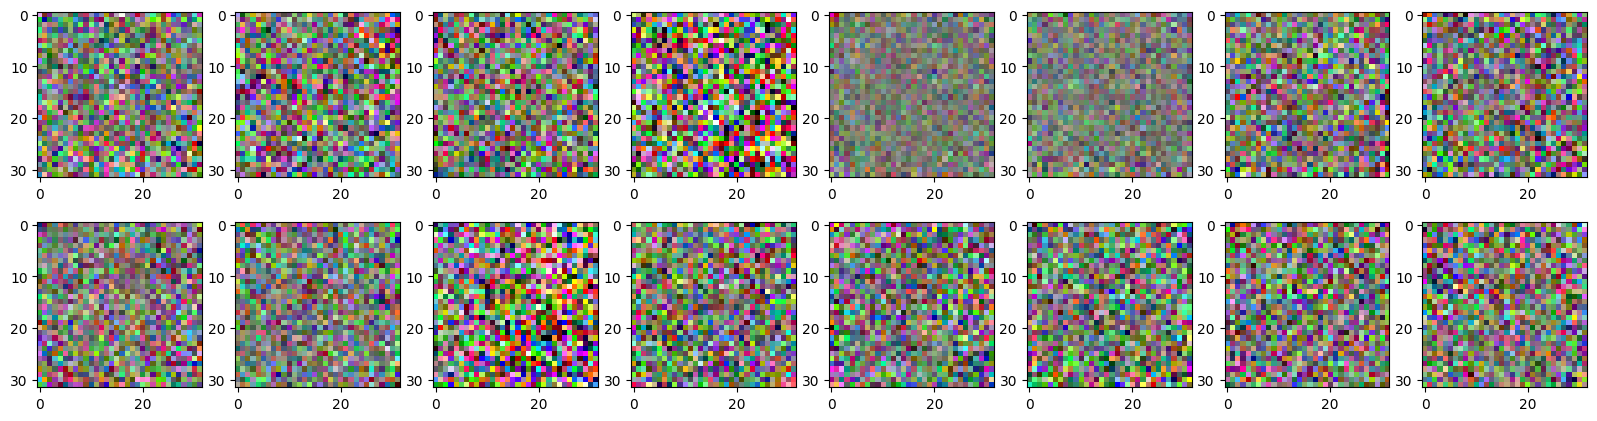

In [ ]:
# Training setup
target_model = create_model(CLASSES, device)
target_model.eval()

MAX_ITERS = 500
PRINT_STEP = 500
LAMBDA_L2 = 1e-6
LAMBDA_TV = 1e-6
ATT_LR = 0.01

_, axes = plt.subplots(2, 8, figsize=(20, 5))
axes = axes.flatten()

target_imgs, target_lbls = target_imgs.to(device), target_lbls.to(device)

init_imgs = torch.randn(sample_batch_size, 3, 32, 32)
imgs = copy.deepcopy(init_imgs).to(device)

imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, print_step=PRINT_STEP,
                                device=device, loss_type="euclidean")

for i in range(sample_batch_size):
    show_img(imgs[i], axes[i])

# MNIST

In [72]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms

DS_SLICE = 1000
IN_CH = 1
IN_W = 28
CLASSES = 10

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
ds_train = MNIST(root="./data", train=True, download=True, transform=transform)
ds_test = MNIST(root="./data", train=False, download=True, transform=transform)

ds_train = Subset(ds_train, indices=np.arange(DS_SLICE))


In [ ]:
# Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 4096),
            nn.ReLU(),
            nn.Linear(4096, 2048),
            nn.ReLU(),
            nn.Linear(2048, 10)
        )

    def forward(self, x):
        return self.net(x)
    
# Training setup
mnist_mlp_model = MLP().to(device)
#train(mnist_mlp_model, ds_train, ds_test, 20)


In [69]:

# LeNet-5
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_net = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),    # 28x28 -> 24x24
            nn.Tanh(),
            nn.AvgPool2d(2),                   # 24x24 -> 12x12
            nn.Conv2d(6, 16, kernel_size=5),   # 12x12 -> 8x8
            nn.Tanh(),
            nn.AvgPool2d(2),                   # 8x8 -> 4x4
            nn.Conv2d(16, 120, kernel_size=4), # 4x4 -> 1x1
            nn.Tanh()
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.conv_net(x)
        x = self.fc(x)
        return x

# Training setup
mnist_cnn_model = LeNet().to(device)
#train(mnist_cnn_model, ds_train, ds_test, 20)

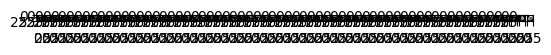

In [73]:
sample_batch_size = 64
attack_batch_size = len(ds_train)
sample_dl = DataLoader(ds_train, batch_size=attack_batch_size, shuffle=False)
target_imgs, target_lbls = next(iter(sample_dl))

_, axes = plt.subplots(1, sample_batch_size)

for i in range(sample_batch_size):
    axes[i].imshow(target_imgs[i, 0], cmap="gray")

Ended epoch 1000/2000
Ended epoch 2000/2000


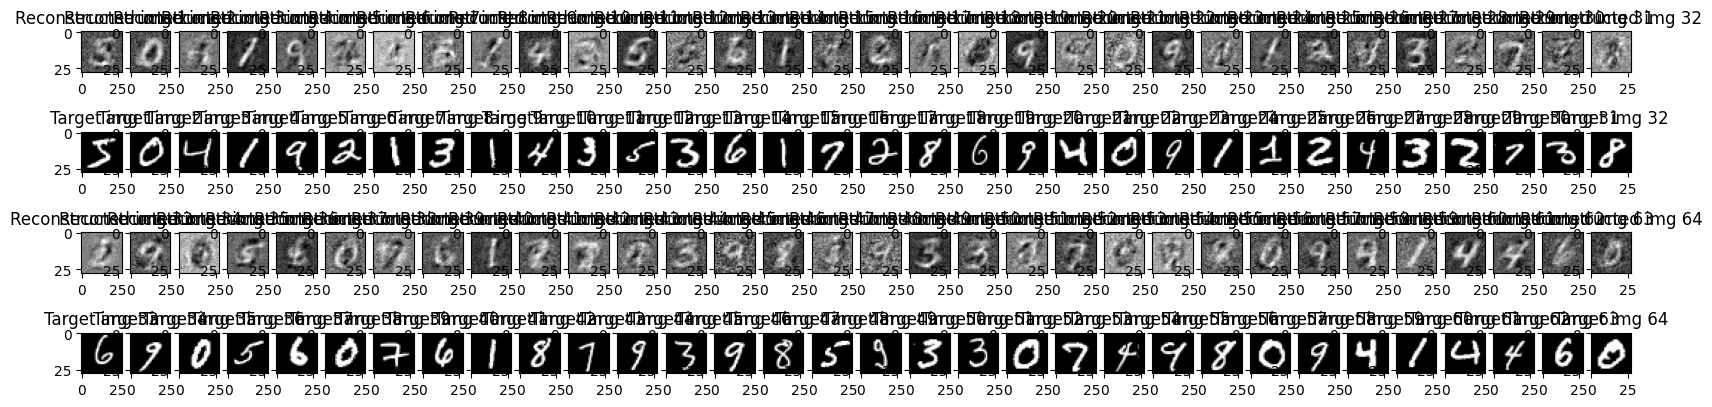

In [98]:
# Model
class MLP1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)
    
# Training setup
mnist_mlp_model = MLP1().to(device)

target_model = mnist_mlp_model

MAX_ITERS = 2000
PRINT_STEP = 1000
LAMBDA_L2 = 0#1e-3
LAMBDA_TV = 0#1e-4
ATT_LR = 0.05



test_dl = DataLoader(ds_test, batch_size=attack_batch_size, shuffle=True)
init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
#init_imgs = torch.randn(attack_batch_size, 1, 28, 28)

imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, init_imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, device=device, print_step=PRINT_STEP)

fig, axes = plt.subplots(2*int(np.ceil(sample_batch_size/32)), np.min([sample_batch_size, 32]), figsize=(20, 5))

for i in range(sample_batch_size):
    offset = 2*(i//32)
    idx = i%32
    axes[0+offset, idx].set_title(f"Reconstructed img {i+1}")
    axes[0+offset, idx].imshow(imgs[i, 0], cmap="gray")

    axes[1+offset, idx].set_title(f"Target img {i+1}")
    axes[1+offset, idx].imshow(target_imgs[i, 0], cmap="gray")



Ended epoch 100/2000
Ended epoch 200/2000
Ended epoch 300/2000
Ended epoch 400/2000
Ended epoch 500/2000
Ended epoch 600/2000
Ended epoch 700/2000
Ended epoch 800/2000
Ended epoch 900/2000
Ended epoch 1000/2000
Ended epoch 1100/2000
Ended epoch 1200/2000
Ended epoch 1300/2000
Ended epoch 1400/2000
Ended epoch 1500/2000
Ended epoch 1600/2000
Ended epoch 1700/2000
Ended epoch 1800/2000
Ended epoch 1900/2000
Ended epoch 2000/2000


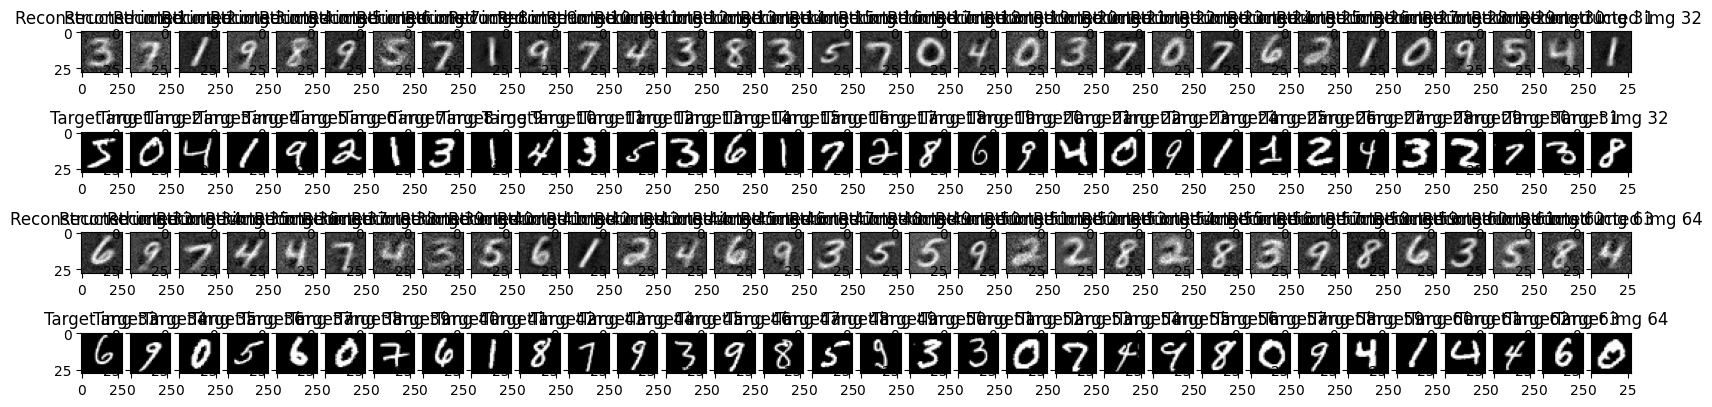

In [111]:
# Model
class MLP2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 10000),
            nn.ReLU(),
            nn.Linear(10000, 5000),
            nn.ReLU(),
            nn.Linear(5000, 10)
        )

    def forward(self, x):
        return self.net(x)
    
# Training setup
mnist_mlp_model = MLP2().to(device)

target_model = mnist_mlp_model

MAX_ITERS = 2000
PRINT_STEP = 100
LAMBDA_L2 = 0#1e-6
LAMBDA_TV = 0#1e-5
ATT_LR = 0.1



test_dl = DataLoader(ds_test, batch_size=attack_batch_size, shuffle=True)
#init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
#init_imgs = torch.randn(attack_batch_size, 1, 28, 28)
init_imgs = torch.randn(sample_batch_size, 1, 28, 28)
#custom_labels = target_lbls[:sample_batch_size]
#custom_labels = torch.full((sample_batch_size,), 5)
custom_labels = torch.randint(0, 10, (sample_batch_size,))

imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, init_imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, 
                                device=device, print_step=PRINT_STEP, loss_type="euclidean", custom_labels=custom_labels)

fig, axes = plt.subplots(2*int(np.ceil(sample_batch_size/32)), np.min([sample_batch_size, 32]), figsize=(20, 5))

for i in range(sample_batch_size):
    offset = 2*(i//32)
    idx = i%32
    axes[0+offset, idx].set_title(f"Reconstructed img {i+1}")
    axes[0+offset, idx].imshow(imgs[i, 0], cmap="gray")

    axes[1+offset, idx].set_title(f"Target img {i+1}")
    axes[1+offset, idx].imshow(target_imgs[i, 0], cmap="gray")



# CIFAR

# LFW

In [180]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


DS_SLICE = 10000
IN_CH = 3
IN_W = 32
CLASSES = 10

DATASET_PATH = "/kaggle/input/lfw-dataset/lfw-deepfunneled"

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

lfw_ds = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

ds_test_size = 0.2
ds_train = Subset(lfw_ds, indices=np.arange(int(DS_SLICE*(1-ds_test_size))))
ds_test = Subset(lfw_ds, indices=np.arange(int(DS_SLICE*(1-ds_test_size)), DS_SLICE))


In [187]:
model = torchvision.models.mobilenet_v2(weights=None)
model.features[0][0].stride = (1, 1)   # remove initial downsampling
model.classifier[1] = nn.Linear(model.last_channel, 10)
lfw_mobilenetv2 = model.to(device)

#train(lfw_mobilenetv2, ds_train, ds_test, 3)

/tmp/ipykernel_133/423216887.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)


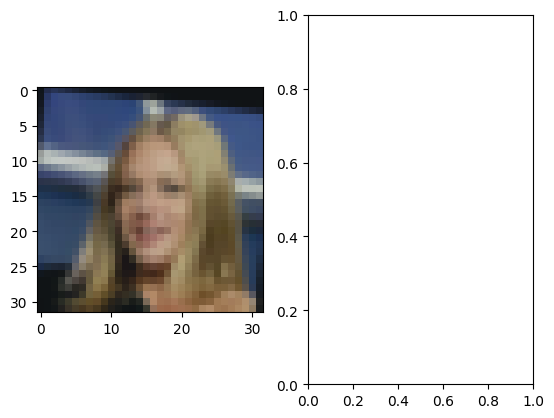

In [181]:
sample_batch_size = 1
attack_batch_size = 1#len(ds_train)
sample_dl = DataLoader(ds_train, batch_size=attack_batch_size, shuffle=False)
target_imgs, target_lbls = next(iter(sample_dl))

_, axes = plt.subplots(1, np.max([2, sample_batch_size]))

for i in range(sample_batch_size):
    show_img(target_imgs[i], axes[i])

/tmp/ipykernel_133/423216887.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)


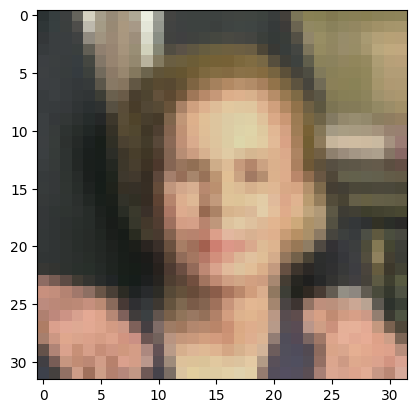

In [182]:
test_dl = DataLoader(ds_test, batch_size=attack_batch_size, shuffle=False)
init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
show_img(init_imgs[0], plt.subplot())

Ended epoch 100/300
Ended epoch 200/300
Ended epoch 300/300


/tmp/ipykernel_133/423216887.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)


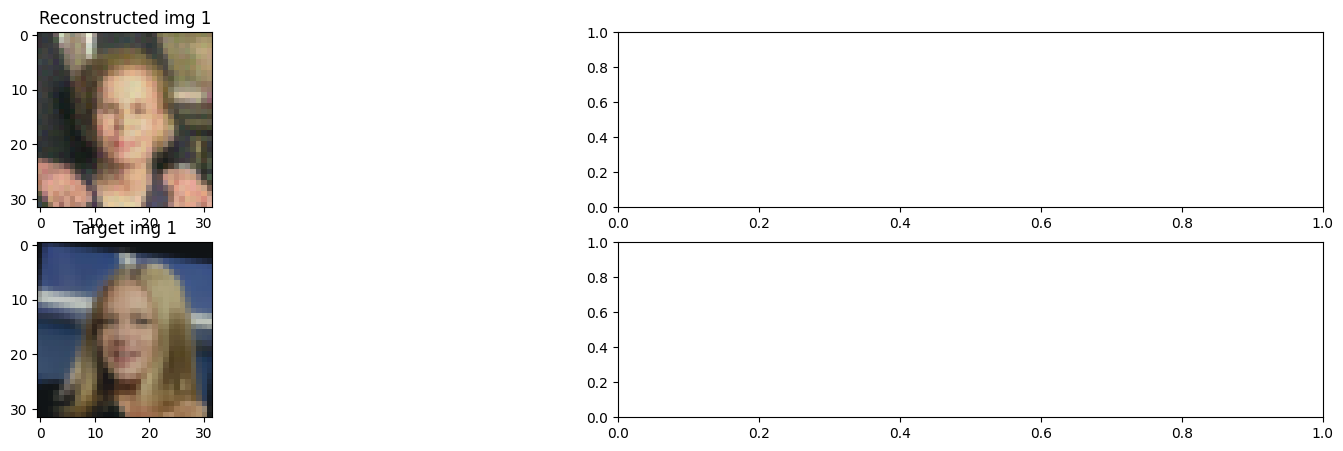

In [195]:
target_model = lfw_mobilenetv2

MAX_ITERS = 300
PRINT_STEP = 100
LAMBDA_L2 = 0#1e-3
LAMBDA_TV = 0#1e-4
ATT_LR = 0.01



test_dl = DataLoader(ds_test, batch_size=attack_batch_size, shuffle=False)
init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
#init_imgs = torch.randn(sample_batch_size, 3, 32, 32)


imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, init_imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, device=device, print_step=PRINT_STEP, loss_type="euclidean")

#fig, axes = plt.subplots(2, sample_batch_size, figsize=(20, 5))
fig, axes = plt.subplots(2, np.max([2, sample_batch_size]), figsize=(20, 5))

for i in range(sample_batch_size):
    axes[0, i].set_title(f"Reconstructed img {i+1}")
    show_img(imgs[i], axes[0, i])

    axes[1, i].set_title(f"Target img {i+1}")
    show_img(target_imgs[i], axes[1, i])


Ended epoch 100/300
Ended epoch 200/300
Ended epoch 300/300


/tmp/ipykernel_133/423216887.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img)


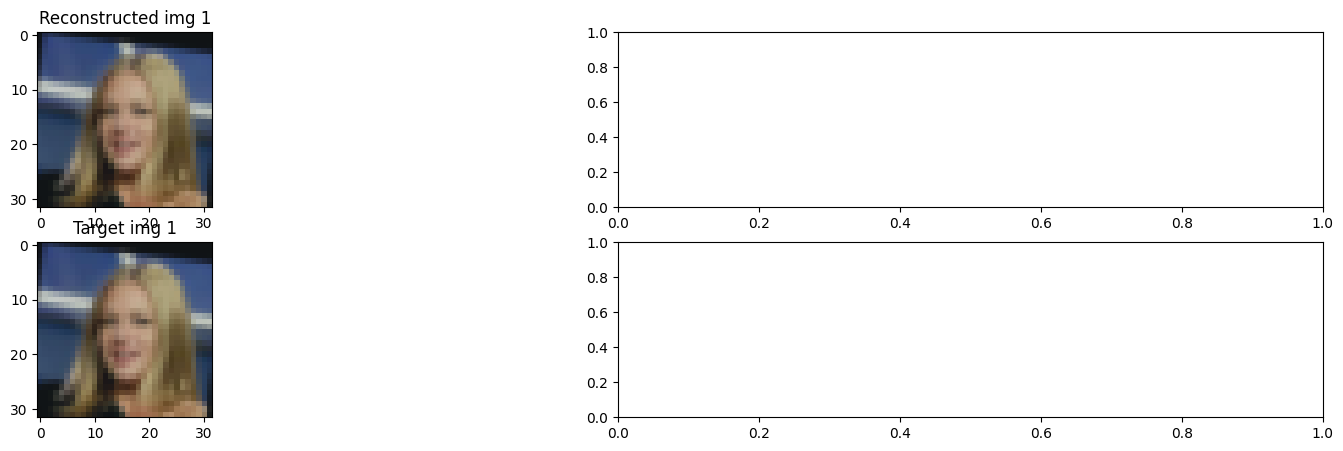

In [197]:
# Model
class MLP2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 10000),
            nn.ReLU(),
            nn.Linear(10000, 5000),
            nn.ReLU(),
            nn.Linear(5000, 10)
        )

    def forward(self, x):
        return self.net(x)
    
# Training setup
lfw_mlp_model = MLP2().to(device)

target_model = lfw_mlp_model

MAX_ITERS = 300
PRINT_STEP = 100
LAMBDA_L2 = 0#1e-3
LAMBDA_TV = 0#1e-4
ATT_LR = 0.05



test_dl = DataLoader(ds_test, batch_size=attack_batch_size, shuffle=False)
init_imgs, _ = copy.deepcopy(next(iter(test_dl)))
#init_imgs = torch.randn(sample_batch_size, 3, 32, 32)


imgs = data_reconstruction_test(target_model, target_imgs, target_lbls, init_imgs, ATT_LR, MAX_ITERS, LAMBDA_L2, LAMBDA_TV, device=device, print_step=PRINT_STEP, loss_type="euclidean")

#fig, axes = plt.subplots(2, sample_batch_size, figsize=(20, 5))
fig, axes = plt.subplots(2, np.max([2, sample_batch_size]), figsize=(20, 5))

for i in range(sample_batch_size):
    axes[0, i].set_title(f"Reconstructed img {i+1}")
    show_img(imgs[i], axes[0, i])

    axes[1, i].set_title(f"Target img {i+1}")
    show_img(target_imgs[i], axes[1, i])